### Inspect data loading and pre-processing

In [12]:
from pathlib import Path
import sys
import soundfile as sf
import pandas as pd
import pprint
import math
import matplotlib.pyplot as plt

root_dir = Path.cwd().resolve()
if not (root_dir / "config.py").exists():
    root_dir = root_dir.parent

sys.path.insert(0, str(root_dir))

from config import FSD50K_AUDIO

In [9]:
# Display file counts and summary statistics for audio data in the current repo.

def total_file_count(data_dir):
    """ Print total number of audio files. """
    total_files = len(list(data_dir.rglob("*.wav")))
    print(f"Total .wav files: {total_files}\n")


total_file_count(FSD50K_AUDIO)

Total .wav files: 10231



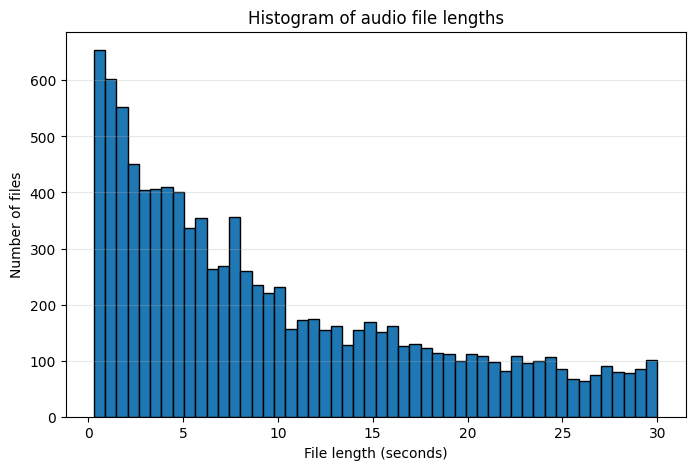

In [13]:
def plot_audio_length_histogram(data_dir, bins=50):
    """ Plot a histogram of audio file lengths in seconds. """
    durations = []

    for file_path in data_dir.rglob("*.wav"):
        info = sf.info(file_path)
        duration = info.frames / info.samplerate
        durations.append(duration)

    if len(durations) == 0:
        print("No audio files found.")
        return

    plt.figure(figsize=(8, 5))
    plt.hist(durations, bins=bins, edgecolor="black")
    plt.xlabel("File length (seconds)")
    plt.ylabel("Number of files")
    plt.title("Histogram of audio file lengths")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

data_dir = Path("../data/fsd50k/FSD50K.eval_audio")
plot_audio_length_histogram(data_dir)
